>[Imports](#scrollTo=9UDeoW4xF3dl&uniqifier=3)

>[Loading dependent files and spliting the data sets](#scrollTo=KxWNiF9DGErf&uniqifier=3)

>[Understanding Data](#scrollTo=-rDnTZCVWKl2&uniqifier=3)

>[Task 1](#scrollTo=PT2c7CnqGdG0&uniqifier=3)

>>[SVM - Without Standardization](#scrollTo=d6gZJKGkXIl7&uniqifier=3)

>>[SVM - With Standardization](#scrollTo=TzFc7ATiWPK2&uniqifier=3)

>>[Observation](#scrollTo=brsee1SPSiTF&uniqifier=3)

>>[Explaination](#scrollTo=7XNhNSJdSlMf&uniqifier=3)

>[Task 2](#scrollTo=5WxW5WsuWSDv&uniqifier=3)

>[Task 3](#scrollTo=kmYE_TcOufLI&uniqifier=3)

>>[Summary](#scrollTo=3lIp3bklr7WY&uniqifier=3)

>[Task 4](#scrollTo=k0QKbeIqug0Q&uniqifier=3)

>>>[Relu, Relu, flatten and softmax](#scrollTo=xkKNwu4dNkHQ&uniqifier=3)

>>>[Relu, Sigmoid, flatten and softmax](#scrollTo=bwEDDWb9NdSS&uniqifier=3)



#Imports

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import tensorflow as tf

#Loading dependent files and spliting the data sets

In [ ]:
wine_data = np.load("/content/wineData-1.npy")
wine_labels = np.load("/content/wineLabels-1.npy")

In [ ]:
train_wine_data, test_wine_data, train_wine_labels, test_wine_labels = train_test_split(
                                                          wine_data,
                                                          wine_labels,
                                                          test_size = 0.2,
                                                          random_state = 20
                                                         )


In [ ]:
(mnist_train_data, mnist_train_labels), (mnist_test_data, mnist_test_labels) = tf.keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print("Train data size: ", len(mnist_train_data))
print("Train data shape: ", mnist_train_data.shape)
print("Test data size: ", len(mnist_test_data))
print("Classification types:", len(np.unique(mnist_train_labels)))

Train data size:  60000
Train data shape:  (60000, 28, 28)
Test data size:  10000
Classification types: 10


#Understanding Data

In [ ]:
print(wine_data.shape, train_wine_data.shape)

(178, 13) (142, 13)


#Task 1

##SVM - Without Standardization

Kernel:linear, c:1, accuracy: 0.9444444444444444
Kernel:linear, c:2, accuracy: 0.9166666666666666
Kernel:linear, c:3, accuracy: 0.9166666666666666
Kernel:linear, c:4, accuracy: 0.9166666666666666
Kernel:poly, c:1, accuracy: 0.6666666666666666
Kernel:poly, c:2, accuracy: 0.6666666666666666
Kernel:poly, c:3, accuracy: 0.6666666666666666
Kernel:poly, c:4, accuracy: 0.6666666666666666
Kernel:rbf, c:1, accuracy: 0.7222222222222222
Kernel:rbf, c:2, accuracy: 0.75
Kernel:rbf, c:3, accuracy: 0.6944444444444444
Kernel:rbf, c:4, accuracy: 0.6944444444444444
Kernel:sigmoid, c:1, accuracy: 0.16666666666666666
Kernel:sigmoid, c:2, accuracy: 0.1111111111111111
Kernel:sigmoid, c:3, accuracy: 0.1111111111111111
Kernel:sigmoid, c:4, accuracy: 0.1111111111111111


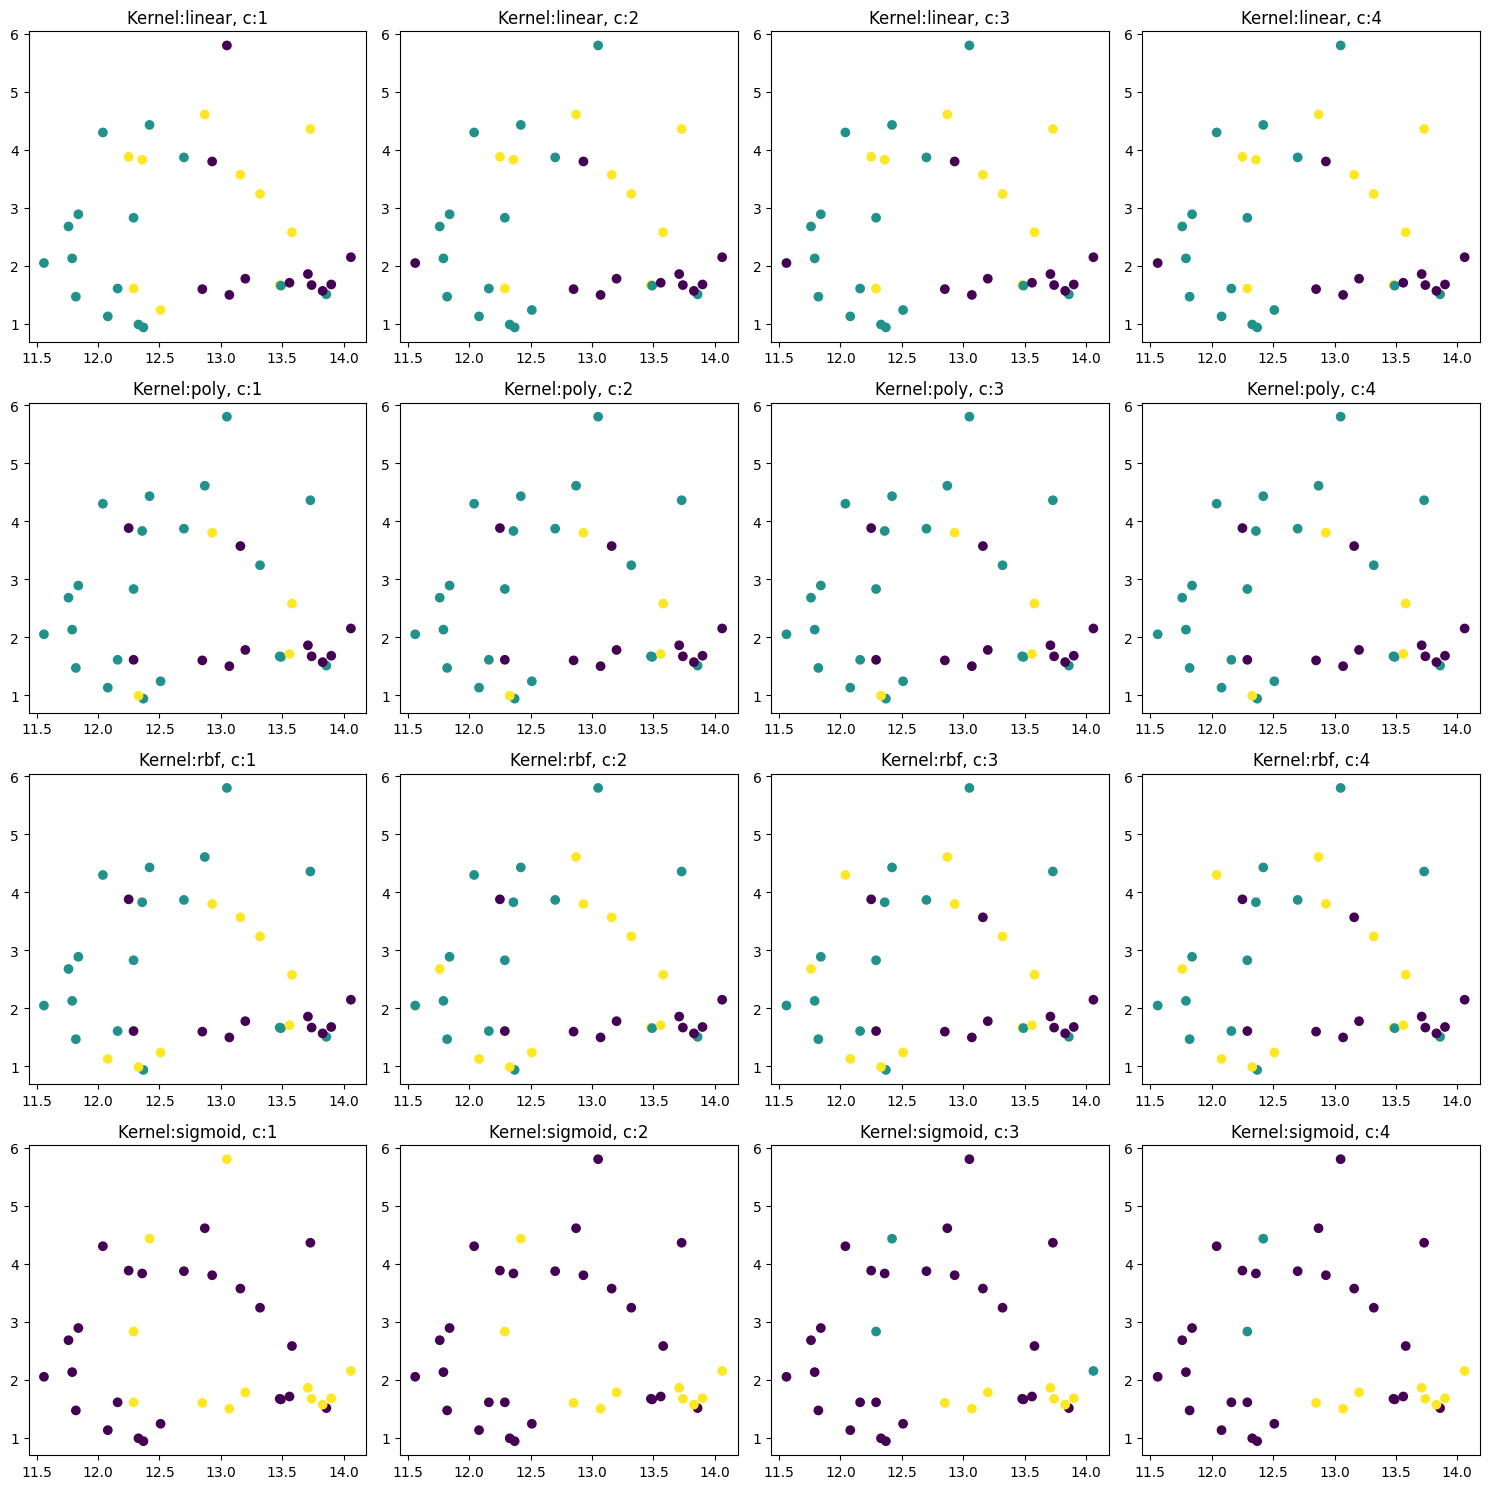

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(15, 15))
#Note: for kernel='precomputed', the input matrix should be a square matrix
for index, kernel in enumerate(['linear', 'poly', 'rbf', 'sigmoid']):
  for c in range(1, 5):
    svm = SVC(kernel=kernel, C=c)
    svm.fit(train_wine_data, train_wine_labels)
    print(f"Kernel:{kernel}, c:{c}, accuracy:", svm.score(test_wine_data, test_wine_labels))

    axes[index, c-1].set_title(f"Kernel:{kernel}, c:{c}")
    axes[index, c-1].scatter(test_wine_data[:, 0], test_wine_data[:, 1], c=svm.predict(test_wine_data))

plt.tight_layout()
plt.show()

##SVM - With Standardization

Kernel:linear, c:1, accuracy: 0.9444444444444444
Kernel:linear, c:2, accuracy: 0.9444444444444444
Kernel:linear, c:3, accuracy: 0.9444444444444444
Kernel:linear, c:4, accuracy: 0.9444444444444444
Kernel:poly, c:1, accuracy: 0.9444444444444444
Kernel:poly, c:2, accuracy: 0.9166666666666666
Kernel:poly, c:3, accuracy: 0.8888888888888888
Kernel:poly, c:4, accuracy: 0.8888888888888888
Kernel:rbf, c:1, accuracy: 1.0
Kernel:rbf, c:2, accuracy: 1.0
Kernel:rbf, c:3, accuracy: 1.0
Kernel:rbf, c:4, accuracy: 1.0
Kernel:sigmoid, c:1, accuracy: 1.0
Kernel:sigmoid, c:2, accuracy: 1.0
Kernel:sigmoid, c:3, accuracy: 1.0
Kernel:sigmoid, c:4, accuracy: 0.8888888888888888


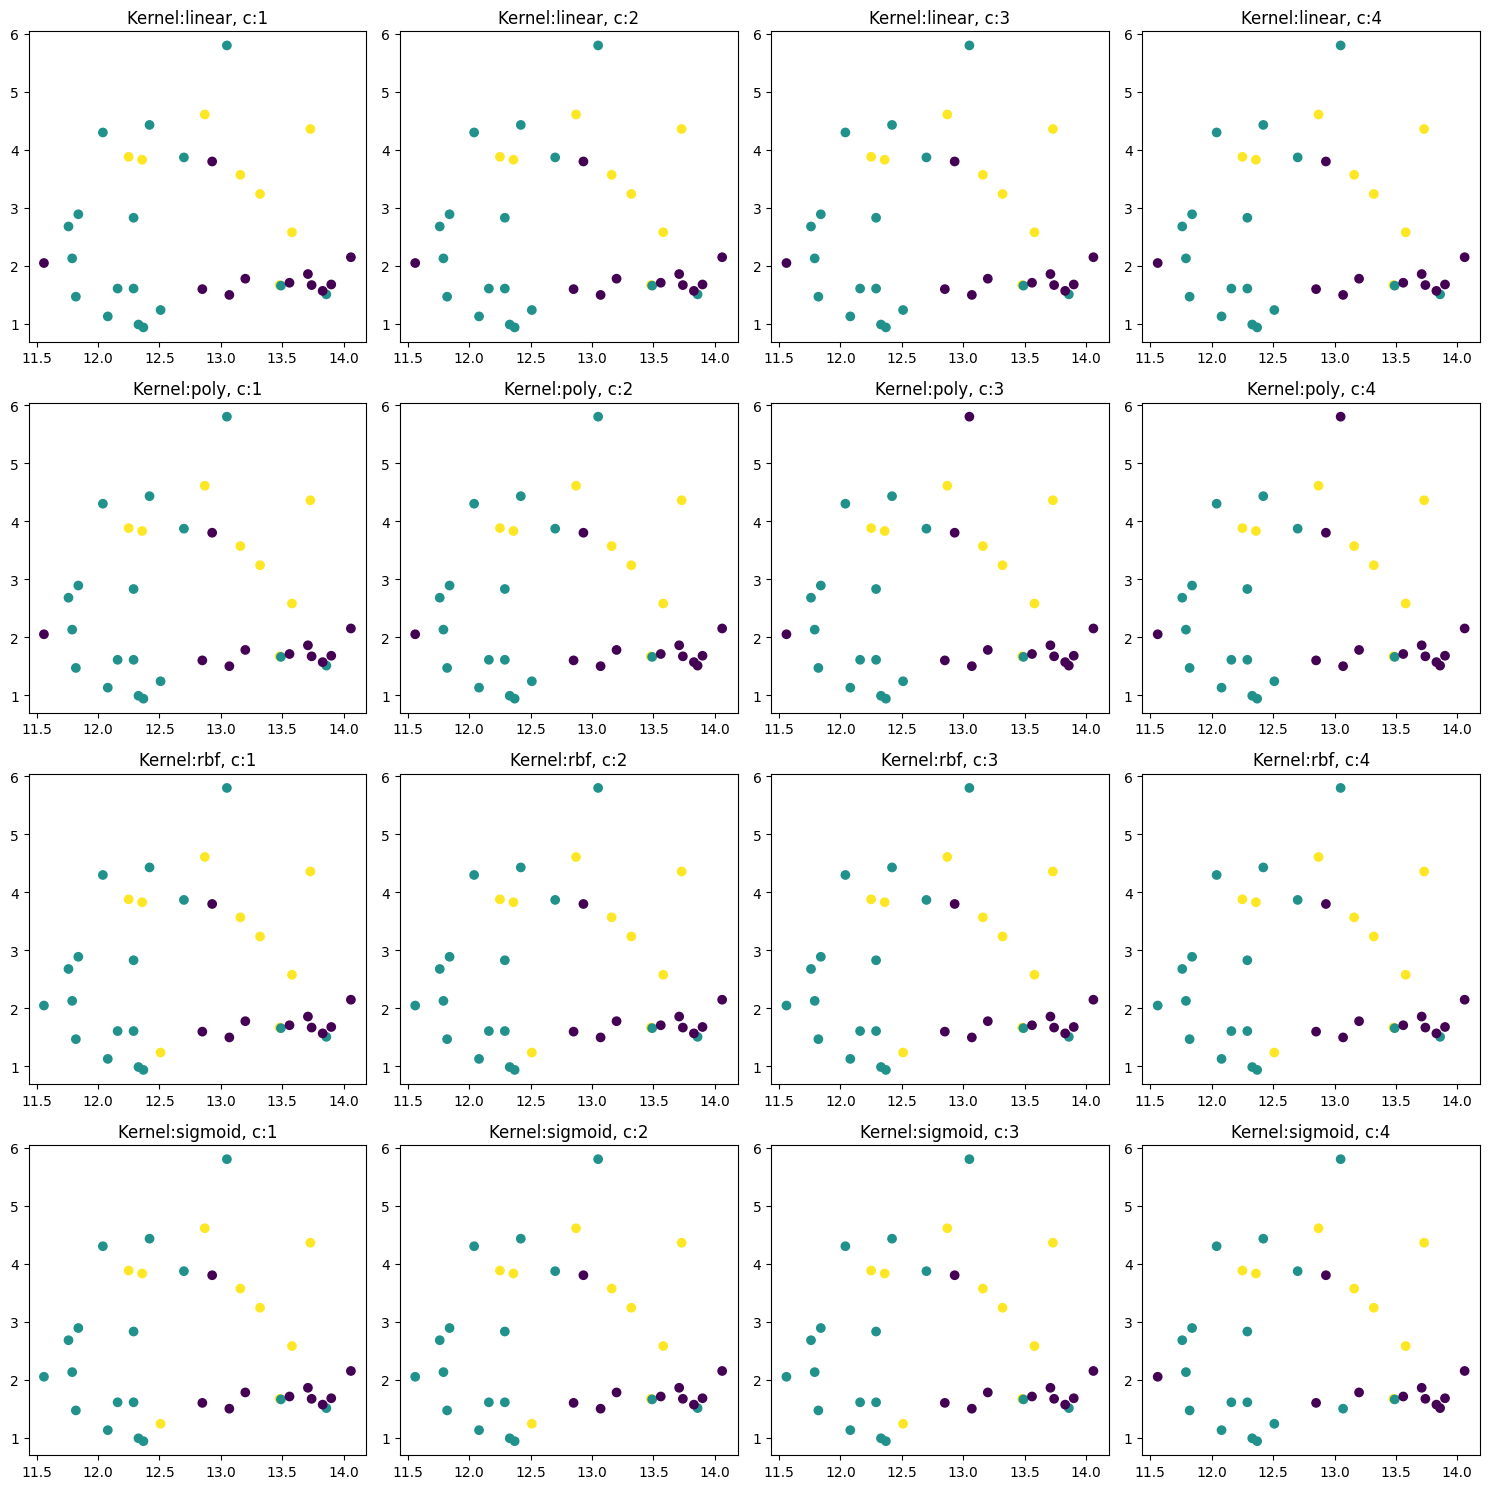

In [ ]:
scaler = StandardScaler()

# Fit the scaler to the data and transform it
scaled_train_wine_data = scaler.fit_transform(train_wine_data)
scaled_test_wine_data = scaler.transform(test_wine_data)

fig, axes = plt.subplots(4, 4, figsize=(15, 15))
#Note: for kernel='precomputed', the input matrix should be a square matrix
for index, kernel in enumerate(['linear', 'poly', 'rbf', 'sigmoid']):
  for c in range(1, 5):
    svm = SVC(kernel=kernel, C=c)
    svm.fit(scaled_train_wine_data, train_wine_labels)
    print(f"Kernel:{kernel}, c:{c}, accuracy:", svm.score(scaled_test_wine_data, test_wine_labels))

    axes[index, c-1].set_title(f"Kernel:{kernel}, c:{c}")
    axes[index, c-1].scatter(test_wine_data[:, 0], test_wine_data[:, 1], c=svm.predict(scaled_test_wine_data))


plt.tight_layout()
plt.show()

##Observation
* Different kernels give varing output as they regularize differently. For example, linear kernels do it with a linear function. poly-> it applies a polynomial function for regularization. For rbf-> it is a guass function and for sigmoid it is simular to activation function of a neural network. More info in this gpt link -> [SVM - kernel breakdown](https://chatgpt.com/share/6744afc8-4014-800f-831c-25b5e150d425)
* For c, here there is no much difference as the dataset is small and is a bit starightforward. However, as you increase c we can observe that the accuracy reduces in most kernels. This is possibly due to overfit of data.

## Explaination
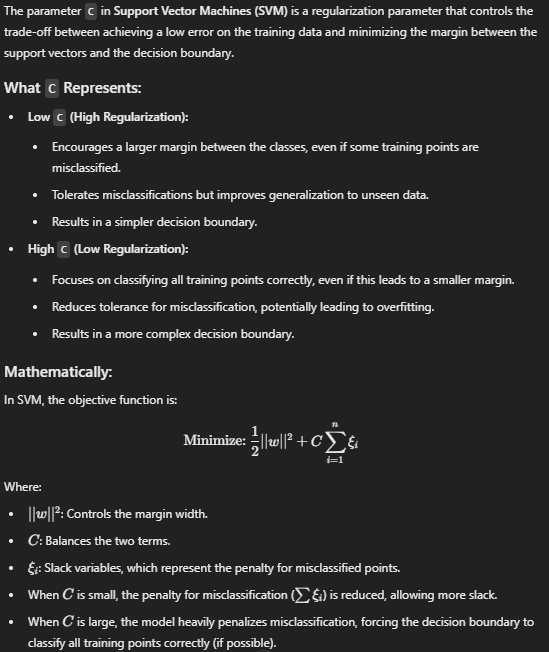

#Task 2

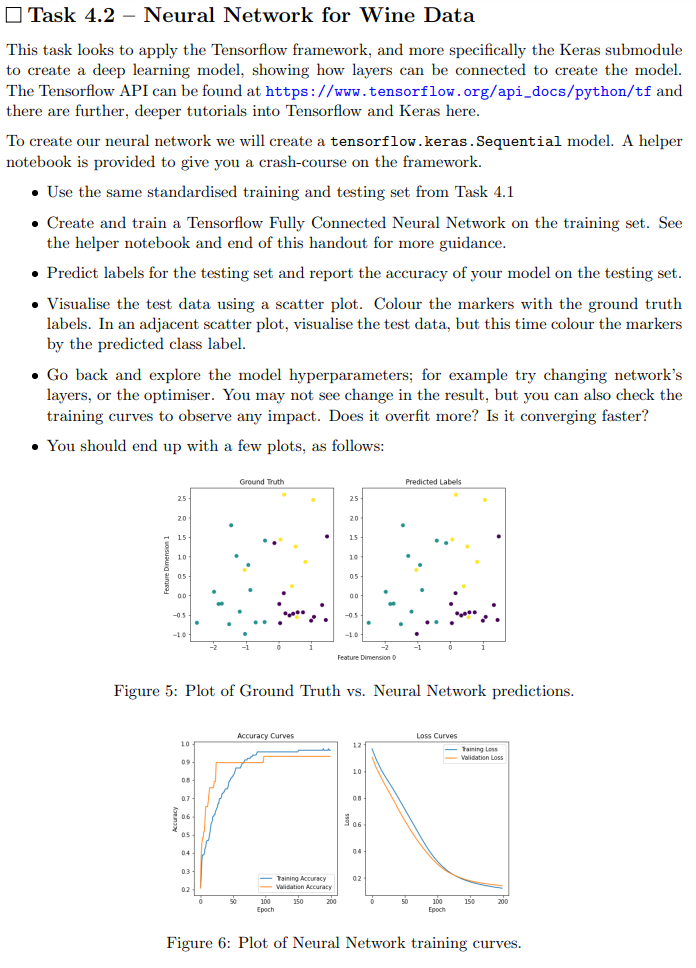

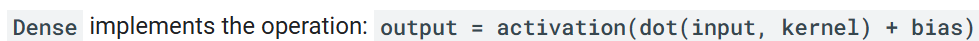

```
The loss argument defines the loss function to minimize. It measures how far off the predictions are from the true labels
  --> SparseCategoricalCrossentropy: This loss function is used for multi-class classification when the target labels are integers (e.g., 0, 1, 2).

Explanation: The metrics argument specifies the evaluation metrics used to judge the model's performance during training and validation.
  --> SparseCategoricalAccuracy: Measures how often predictions match integer labels.
```



In [ ]:
model = tf.keras.Sequential(layers=[
    tf.keras.layers.Dense(4, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.relu),
    tf.keras.layers.Dense(len(np.unique(wine_labels)), activation=tf.nn.softmax)])


model.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

history = model.fit(train_wine_data,
                    train_wine_labels,
                    epochs=1000,
                    validation_split=0.2,
                    verbose=1
                    )

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 106ms/step - loss: 244.8339 - sparse_categorical_accuracy: 0.2533 - val_loss: 293.7906 - val_sparse_categorical_accuracy: 0.2069
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 237.5095 - sparse_categorical_accuracy: 0.2491 - val_loss: 271.1288 - val_sparse_categorical_accuracy: 0.2069
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 216.7589 - sparse_categorical_accuracy: 0.3074 - val_loss: 249.3344 - val_sparse_categorical_accuracy: 0.2069
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 168.6053 - sparse_categorical_accuracy: 0.3262 - val_loss: 228.2552 - val_sparse_categorical_accuracy: 0.2069
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 191.4534 - sparse_categorical_accuracy: 0.2616 - val_loss: 207.2412 - val_sparse_categorical_accuracy: 0.2069
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - loss: 156.0684 - sparse_categorical_accuracy: 0.3022 - val_loss: 186.8446 - val_sparse_categorical_ac

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 4)                   │              56 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │              50 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 3)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 419 (1.64 KB)

 Trainable params: 139 (556.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 280 (1.10 KB)

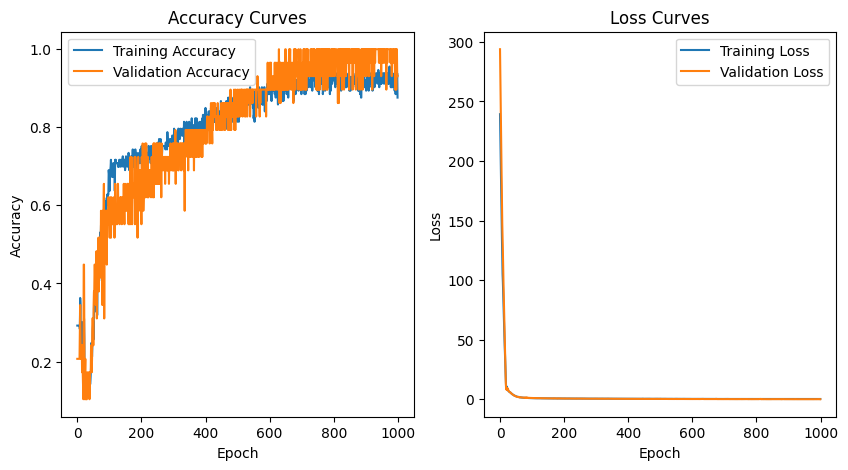

In [ ]:
plt.figure(figsize=[10,5])
plt.subplot(121)
plt.plot(history.history['sparse_categorical_accuracy'])
plt.plot(history.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curves')

plt.subplot(122)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')
plt.show()

In [ ]:
results = model.evaluate(test_wine_data, test_wine_labels)

print(f'Test set loss: {results[0]:0.2f}, test set accuracy: {results[1]*100:0.2f}%')

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1366 - sparse_categorical_accuracy: 0.9711 
Test set loss: 0.14, test set accuracy: 97.22%


2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


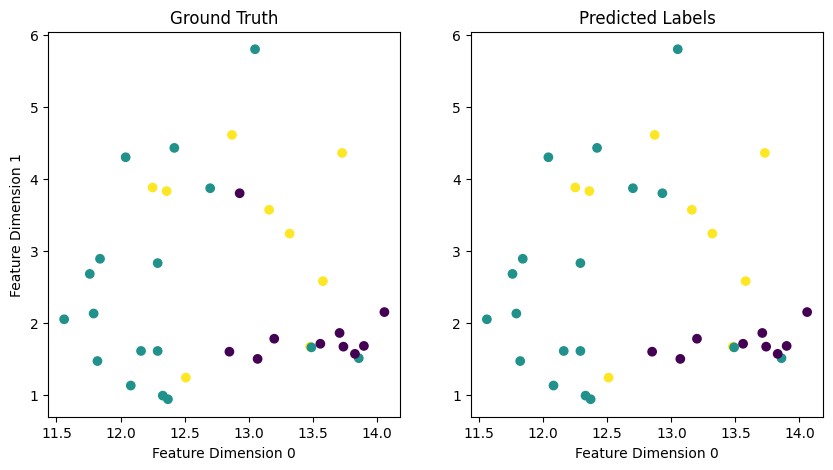

In [ ]:
plt.figure(figsize=[10,5])
plt.subplot(121)
plt.scatter(test_wine_data[:,0], test_wine_data[:,1], c=test_wine_labels)
plt.ylabel('Feature Dimension 1')
plt.xlabel('Feature Dimension 0')
plt.title('Ground Truth')
plt.subplot(122)
plt.title('Predicted Labels')
plt.xlabel('Feature Dimension 0')
plt.scatter(test_wine_data[:,0], test_wine_data[:,1], c=np.argmax(model.predict(test_wine_data), axis=1))
plt.show()

#Task 3

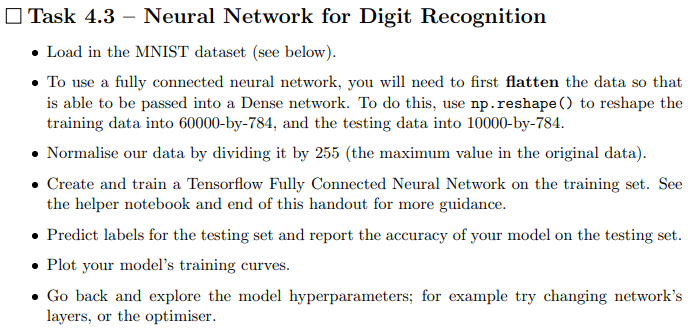

In [ ]:
output_classifications = 10 #Hardcoding this as the no of digit is universally constant

#Flatten into sample*feature due to pre-requisites for 'Dense' layer
flattened_mnist_train_data = mnist_train_data.reshape(len(mnist_train_data), 784)
flattened_mnist_test_data = mnist_test_data.reshape(len(mnist_test_data), 784)

#Normalize the data to reduce the deviation in the magnitude
normalized_mnist_train_data = flattened_mnist_train_data / 255.0
normalized_mnist_test_data = flattened_mnist_test_data / 255.0

#Define the model with layers and hyperparams as per requiremnets
model_mnist = tf.keras.Sequential(layers=[
    tf.keras.layers.Dense(5, activation=tf.nn.relu),
    tf.keras.layers.Dense(output_classifications, activation=tf.nn.softmax,)])

#Add the optimizer, loss, metrics and finalize the configuration
model_mnist.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_mnist = model_mnist.fit(normalized_mnist_train_data,
                                mnist_train_labels,
                                epochs = 7,
                                validation_split = 0.2,
                                verbose = 1
                                )

Epoch 1/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 1.4231 - sparse_categorical_accuracy: 0.5013 - val_loss: 0.5702 - val_sparse_categorical_accuracy: 0.8384
Epoch 2/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.5717 - sparse_categorical_accuracy: 0.8324 - val_loss: 0.5019 - val_sparse_categorical_accuracy: 0.8559
Epoch 3/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.5205 - sparse_categorical_accuracy: 0.8522 - val_loss: 0.4600 - val_sparse_categorical_accuracy: 0.8677
Epoch 4/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4785 - sparse_categorical_accuracy: 0.8637 - val_loss: 0.4348 - val_sparse_categorical_accuracy: 0.8734
Epoch 5/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.4576 - sparse_categorical_accuracy: 0.8742 - val_loss: 0.4094 - val_sparse_categorical_accuracy: 0.8823
Epoch 6/7
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.4295 - sparse_categorical_accuracy: 0.8792 - val_loss: 0.3941 - val_sparse_categorical_accuracy: 0.889

In [ ]:
#Model overview
model_mnist.summary(show_trainable=True)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ Layer (type)                        ┃ Output Shape                 ┃       Param # ┃ Traina… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ dense_3 (Dense)                     │ (32, 5)                      │         3,925 │    Y    │
├─────────────────────────────────────┼──────────────────────────────┼───────────────┼─────────┤
│ dense_4 (Dense)                     │ (32, 10)                     │            60 │    Y    │
└─────────────────────────────────────┴──────────────────────────────┴───────────────┴─────────┘

 Total params: 11,957 (46.71 KB)

 Trainable params: 3,985 (15.57 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,972 (31.14 KB)

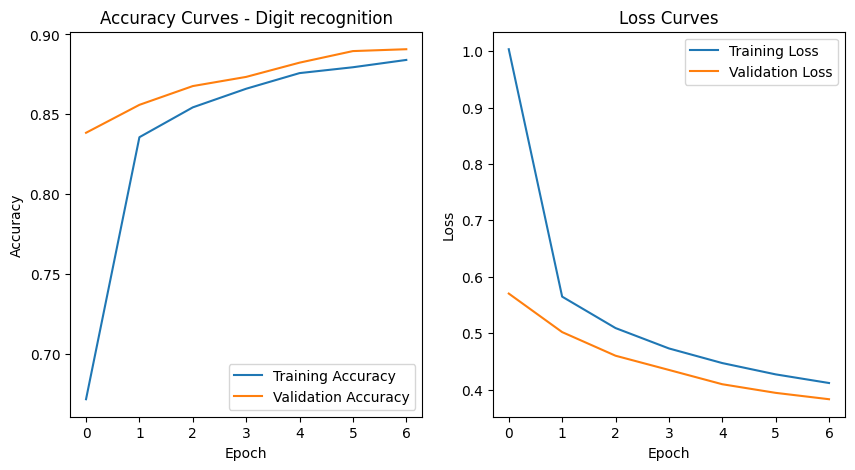

In [ ]:
plt.figure(figsize=[10,5])

#Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_mnist.history['sparse_categorical_accuracy'])
plt.plot(history_mnist.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curves - Digit recognition')

#Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_mnist.history['loss'])
plt.plot(history_mnist.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')

plt.show()

In [ ]:
#Use the testing data to check the accuraccy and if the model needs any tuning
results_mnist = model_mnist.evaluate(normalized_mnist_test_data, mnist_test_labels)

print(f'Test set loss: {results_mnist[0]:0.2f}, test set accuracy: {results_mnist[1]*100:0.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.4438 - sparse_categorical_accuracy: 0.8779
Test set loss: 0.40, test set accuracy: 89.19%


##Summary
1. Trained the model by increasing, decreasing the neurons, epochs and layers. Based on the output covers and moldel size finalized the model with minimal difference between the losses and leas epochs with high test results and minimal model size

#Task 4

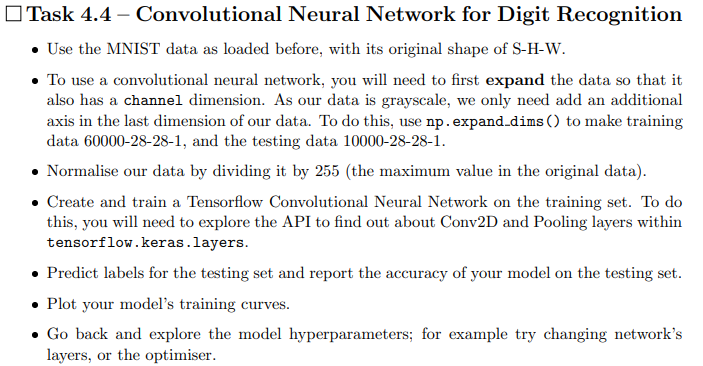

###Relu, Relu, flatten and softmax

In [ ]:
#Add the channel dimension - Pre-requisite for Conv2D
updated_mnist_train_data = np.expand_dims(mnist_train_data, axis=3)
updated_mnist_test_data = np.expand_dims(mnist_test_data, axis=3)

#Normalize the data
normalized_mnist_train_data = updated_mnist_train_data / 255.0
normalized_mnist_test_data = updated_mnist_test_data / 255.0

#Define the model with layers and hyperparams as per requiremnets
model_cnn_mnist = tf.keras.Sequential(layers=[
    tf.keras.layers.Conv2D(14, kernel_size=(14,14), activation=tf.nn.relu),
    tf.keras.layers.Conv2D(7, kernel_size=(7,7), activation=tf.nn.relu),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(output_classifications, activation = tf.nn.softmax)])

#Add the optimizer, loss, metrics and finalize the configuration
model_cnn_mnist.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_cnn_mnist1 = model_cnn_mnist.fit(normalized_mnist_train_data,
                                mnist_train_labels,
                                epochs = 3,
                                validation_split = 0.3,
                                verbose = 1
                                )

Epoch 1/3
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - loss: 0.5403 - sparse_categorical_accuracy: 0.8289 - val_loss: 0.1410 - val_sparse_categorical_accuracy: 0.9575
Epoch 2/3
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - loss: 0.1357 - sparse_categorical_accuracy: 0.9590 - val_loss: 0.1120 - val_sparse_categorical_accuracy: 0.9661
Epoch 3/3
1313/1313 ━━━━━━━━━━━━━━━━━━━━ 82s 31ms/step - loss: 0.1006 - sparse_categorical_accuracy: 0.9683 - val_loss: 0.0962 - val_sparse_categorical_accuracy: 0.9725


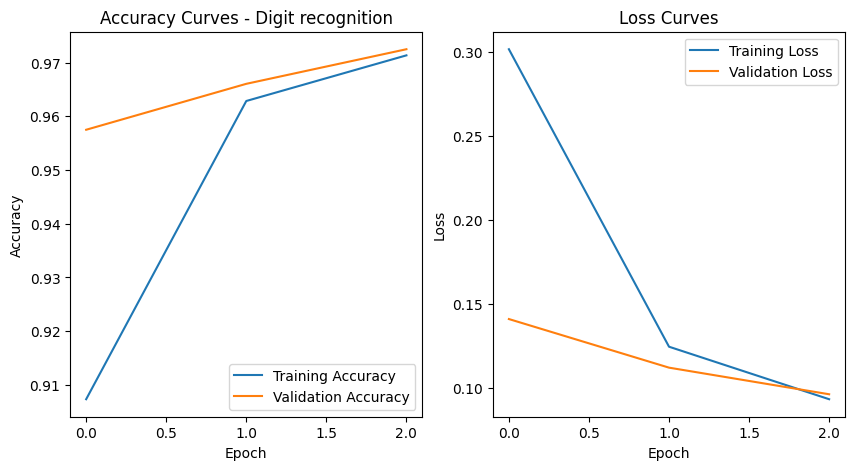

In [ ]:
plt.figure(figsize=[10,5])

#Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_cnn_mnist1.history['sparse_categorical_accuracy'])
plt.plot(history_cnn_mnist1.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curves - Digit recognition')

#Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_cnn_mnist1.history['loss'])
plt.plot(history_cnn_mnist1.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')

plt.show()

###Relu, Sigmoid, flatten and softmax

In [ ]:
#Add the channel dimension - Pre-requisite for Conv2D
updated_mnist_train_data = np.expand_dims(mnist_train_data, axis=3)
updated_mnist_test_data = np.expand_dims(mnist_test_data, axis=3)

#Normalize the data
normalized_mnist_train_data = updated_mnist_train_data / 255.0
normalized_mnist_test_data = updated_mnist_test_data / 255.0

#Define the model with layers and hyperparams as per requiremnets
model_cnn_mnist = tf.keras.Sequential(layers=[
    tf.keras.layers.Conv2D(14, kernel_size=(10,10), activation=tf.nn.relu),
    tf.keras.layers.Conv2D(7, kernel_size=(5,5), activation=tf.nn.sigmoid),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(output_classifications, activation = tf.nn.softmax)])

#Add the optimizer, loss, metrics and finalize the configuration
model_cnn_mnist.compile(optimizer = tf.keras.optimizers.Adam(),
              loss = tf.keras.losses.SparseCategoricalCrossentropy(),
              metrics = [tf.keras.metrics.SparseCategoricalAccuracy()])

#Train the model with train data set and include validation to see the accuracy
history_cnn_mnist2 = model_cnn_mnist.fit(normalized_mnist_train_data,
                                mnist_train_labels,
                                epochs = 2,
                                validation_split = 0.2,
                                verbose = 1
                                )

Epoch 1/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 52s 33ms/step - loss: 0.6893 - sparse_categorical_accuracy: 0.7794 - val_loss: 0.1326 - val_sparse_categorical_accuracy: 0.9595
Epoch 2/2
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 35ms/step - loss: 0.1180 - sparse_categorical_accuracy: 0.9644 - val_loss: 0.1032 - val_sparse_categorical_accuracy: 0.9671


In [ ]:
#Model overview
model_cnn_mnist.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (32, 19, 19, 14)            │           1,414 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (32, 15, 15, 7)             │           2,457 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (32, 1575)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (32, 10)                    │          15,760 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 58,895 (230.06 KB)

 Trainable params: 19,631 (76.68 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 39,264 (153.38 KB)

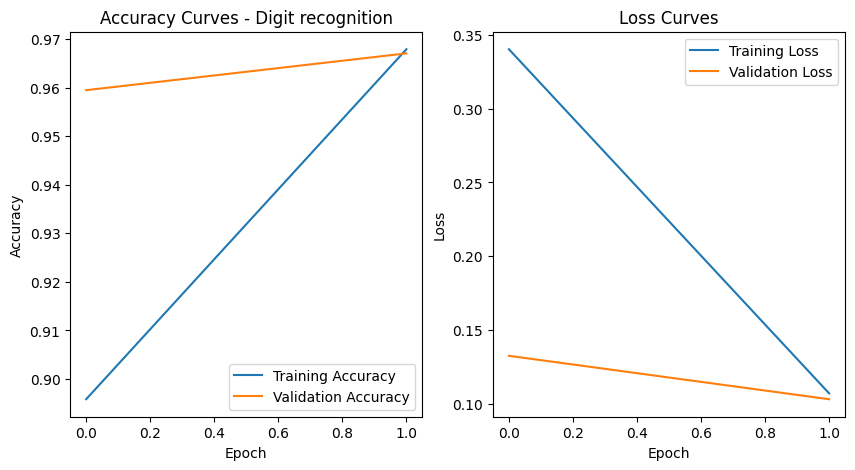

In [ ]:
plt.figure(figsize=[10,5])

#Plot lines for training vs validation accuracy
plt.subplot(121)
plt.plot(history_cnn_mnist2.history['sparse_categorical_accuracy'])
plt.plot(history_cnn_mnist2.history['val_sparse_categorical_accuracy'])
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy',
           'Validation Accuracy'])
plt.title('Accuracy Curves - Digit recognition')

#Plot lines for training vs validation loss
plt.subplot(122)
plt.plot(history_cnn_mnist2.history['loss'])
plt.plot(history_cnn_mnist2.history['val_loss'])
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss',
           'Validation Loss'])
plt.title('Loss Curves')

plt.show()

In [ ]:
#Use the testing data to check the accuraccy and if the model needs any tuning
results_cnn_mnist = model_cnn_mnist.evaluate(normalized_mnist_test_data, mnist_test_labels)

print(f'Test set loss: {results_cnn_mnist[0]:0.2f}, test set accuracy: {results_cnn_mnist[1]*100:0.2f}%')

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.1054 - sparse_categorical_accuracy: 0.9668
Test set loss: 0.09, test set accuracy: 97.14%
